# Exercise session: Patos Lagoon Estuary Buoy Analysis & COARE 3.5 Bulk Flux Modeling

## 1. Introduction and Objectives
This notebook processes and analyzes estuarine buoy measurements from the **SIMCOSTA RS-2** station deployed in the **Patos Lagoon estuary** (Brazil).

### Key Objectives:
1. **Data Ingestion & Merging**: Load high-frequency meteorological (`SIMCOSTA_RS-2_MET`) and oceanographic (`SIMCOSTA_RS-2_OCEAN`) datasets, construct a unified datetime index, and merge them via an inner join.
2. **Parameter Selection**: Extract key atmospheric forcing and surface variables: wind speed ($WS$), air temperature ($T_{air}$), relative humidity ($RH$), sea/water surface temperature ($SST$), barometric pressure ($P$), and solar radiation ($S_{Up}$).schemaName
3. **COARE 3.5 Bulk Algorithm Execution**: Feed the meteorological and oceanographic time series into the **COARE 3.5 bulk flux algorithm** (`coare35vn.py`) to estimate estuarine turbulent heat fluxes ($H$ and $LE$).
4. **Diagnostic Visualization**: Generate a clean 5-panel time-series plot comparing surface temperatures, relative humidity, wind speed, solar radiation, and turbulent fluxes ($H$ & $LE$).

---

## 2. Environment Setup
Import standard scientific libraries and the COARE 3.5 algorithm function.

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from coare35vn import coare35vn

## 3. Loading and Merging SIMCOSTA Buoy Datasets
Read the meteorological and oceanographic CSV files, skip metadata header rows, parse datetime component columns, and merge both datasets on a unified index.

In [14]:
# 1. Load SIMCOSTA meteorological and oceanographic datasets
filename_met = 'data/SIMCOSTA/SIMCOSTA_RS-2_MET_2019-02-13_2019-02-19.csv'
df_met = pd.read_csv(filename_met, skiprows=range(39), na_values='NULL')

filename_oce = 'data/SIMCOSTA/SIMCOSTA_RS-2_OCEAN__2019-02-13_2019-02-19.csv'
df_oce = pd.read_csv(filename_oce, skiprows=range(34), na_values='NULL')

# 2. Function to create a standard datetime index from component columns
def create_datetime_index(df):
    dt_cols = ['YEAR', 'MONTH', 'DAY', 'HOUR', 'MINUTE', 'SECOND']
    datetime_series = pd.to_datetime(df[dt_cols])
    df = df.copy()
    df['datetime'] = datetime_series
    return df.set_index('datetime')

# Apply index builder to both dataframes
df_met_idx = create_datetime_index(df_met)
df_oce_idx = create_datetime_index(df_oce)

# 3. Merge datasets on their common datetime index
df_merged = pd.merge(df_met_idx, df_oce_idx, left_index=True, right_index=True, how='inner')

# Inspect merged columns
print("Merged columns:", df_merged.columns)
df_merged.head()

Merged columns: Index(['YEAR_x', 'MONTH_x', 'DAY_x', 'HOUR_x', 'MINUTE_x', 'SECOND_x',
       'Avg_Air_Press', 'Gust_Sp', 'Avg_Wnd_Sp', 'Avg_Dew', 'Avg_Hmt',
       'Avg_Air_Tmp', 'Avg_Sol_Rad', 'Avg_Wnd_Dir_N', 'YEAR_y', 'MONTH_y',
       'DAY_y', 'HOUR_y', 'MINUTE_y', 'SECOND_y', 'Avg_Sal', 'Avg_W_Tmp1',
       'Avg_W_Tmp2'],
      dtype='object')


,YEAR_x,MONTH_x,DAY_x,HOUR_x,MINUTE_x,SECOND_x,Avg_Air_Press,Gust_Sp,Avg_Wnd_Sp,Avg_Dew,...,Avg_Wnd_Dir_N,YEAR_y,MONTH_y,DAY_y,HOUR_y,MINUTE_y,SECOND_y,Avg_Sal,Avg_W_Tmp1,Avg_W_Tmp2
datetime,,,,,,,,,,,,,,,,,,,,,
2019-02-13 00:21:40,2019,2,13,0,21,40,1021.53,13.6,10.7,15.3,...,190.55,2019,2,13,0,21,40,31.74,24.53,24.48
2019-02-13 00:51:40,2019,2,13,0,51,40,1021.56,12.2,9.9,14.2,...,178.55,2019,2,13,0,51,40,31.69,24.52,24.53
2019-02-13 01:21:40,2019,2,13,1,21,40,1021.59,9.9,8.3,13.8,...,186.55,2019,2,13,1,21,40,31.72,24.47,24.47
2019-02-13 01:51:40,2019,2,13,1,51,40,1021.46,11.1,9.0,14.2,...,184.55,2019,2,13,1,51,40,31.68,24.49,24.48
2019-02-13 02:21:40,2019,2,13,2,21,40,1021.27,9.7,8.0,14.5,...,175.55,2019,2,13,2,21,40,31.70,24.37,24.37


## 4. Subset Target Variables
Extract the primary forcing parameters required for bulk flux estimation from the merged dataframe.

In [15]:
# Select necessary variables for air-water exchange analysis
vars_sel = ['Avg_Wnd_Sp', 'Avg_Air_Tmp', 'Avg_Hmt', 'Avg_W_Tmp1', 'Avg_Air_Press', 'Avg_Sol_Rad']
df_sel = df_merged[vars_sel].copy()
df_sel.head()

,Avg_Wnd_Sp,Avg_Air_Tmp,Avg_Hmt,Avg_W_Tmp1,Avg_Air_Press,Avg_Sol_Rad
datetime,,,,,,
2019-02-13 00:21:40,10.7,21.0,69.5,24.53,1021.53,17.46
2019-02-13 00:51:40,9.9,21.2,64.3,24.52,1021.56,17.40
2019-02-13 01:21:40,8.3,21.1,62.9,24.47,1021.59,17.48
2019-02-13 01:51:40,9.0,21.2,64.1,24.49,1021.46,17.80
2019-02-13 02:21:40,8.0,21.0,66.1,24.37,1021.27,18.08


## 5. COARE 3.5 Bulk Flux Computations
Run the COARE 3.5 algorithm specifying sensor heights, approximate estuary latitude, and incoming radiation parameters to estimate turbulent heat fluxes.

In [16]:
# Compute turbulent fluxes using COARE 3.5 algorithm
A = coare35vn(
    df_sel['Avg_Wnd_Sp'].values,
    df_sel['Avg_Air_Tmp'].values,
    df_sel['Avg_Hmt'].values,
    df_sel['Avg_W_Tmp1'].values,
    P=df_sel['Avg_Air_Press'].values,
    Rs=df_sel['Avg_Sol_Rad'].values,
    Rl=310,          # Incoming longwave radiation estimate (W/m²)
    zu=1.8,          # Anemometer height (meters)
    zt=1.8,          # Temperature sensor height (meters)
    zq=1.8,          # Humidity sensor height (meters)
    lat=-32.13,      # Approximate latitude for Patos Lagoon / SIMCOSTA RS-2 station
    zi=500,          # Boundary layer height (meters)
    rain=np.zeros_like(df_sel['Avg_Wnd_Sp'].values),
    jcool=1
)

/home/lacrio/cryoextremes-practicals/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


## 6. Post-Processing and Quality Filtering
Extract Sensible Heat Flux ($H$) and Latent Heat Flux ($LE$) from the COARE output array and apply physical bounds/threshold filtering.

In [17]:
# Extract Sensible Heat Flux (H) and Latent Heat Flux (LE) with threshold filtering
df_sel['H'] = np.where(np.abs(A[:, 2]) > 150, np.nan, A[:, 2])
df_sel['LE'] = np.where(np.abs(A[:, 3]) > 150, np.nan, A[:, 3])

## 7. Multi-Panel Estuarine Forcing & Flux Visualization
Generate a comprehensive 5-panel diagnostic figure displaying air/water temperatures, relative humidity, wind speed, solar radiation, and estimated turbulent fluxes.

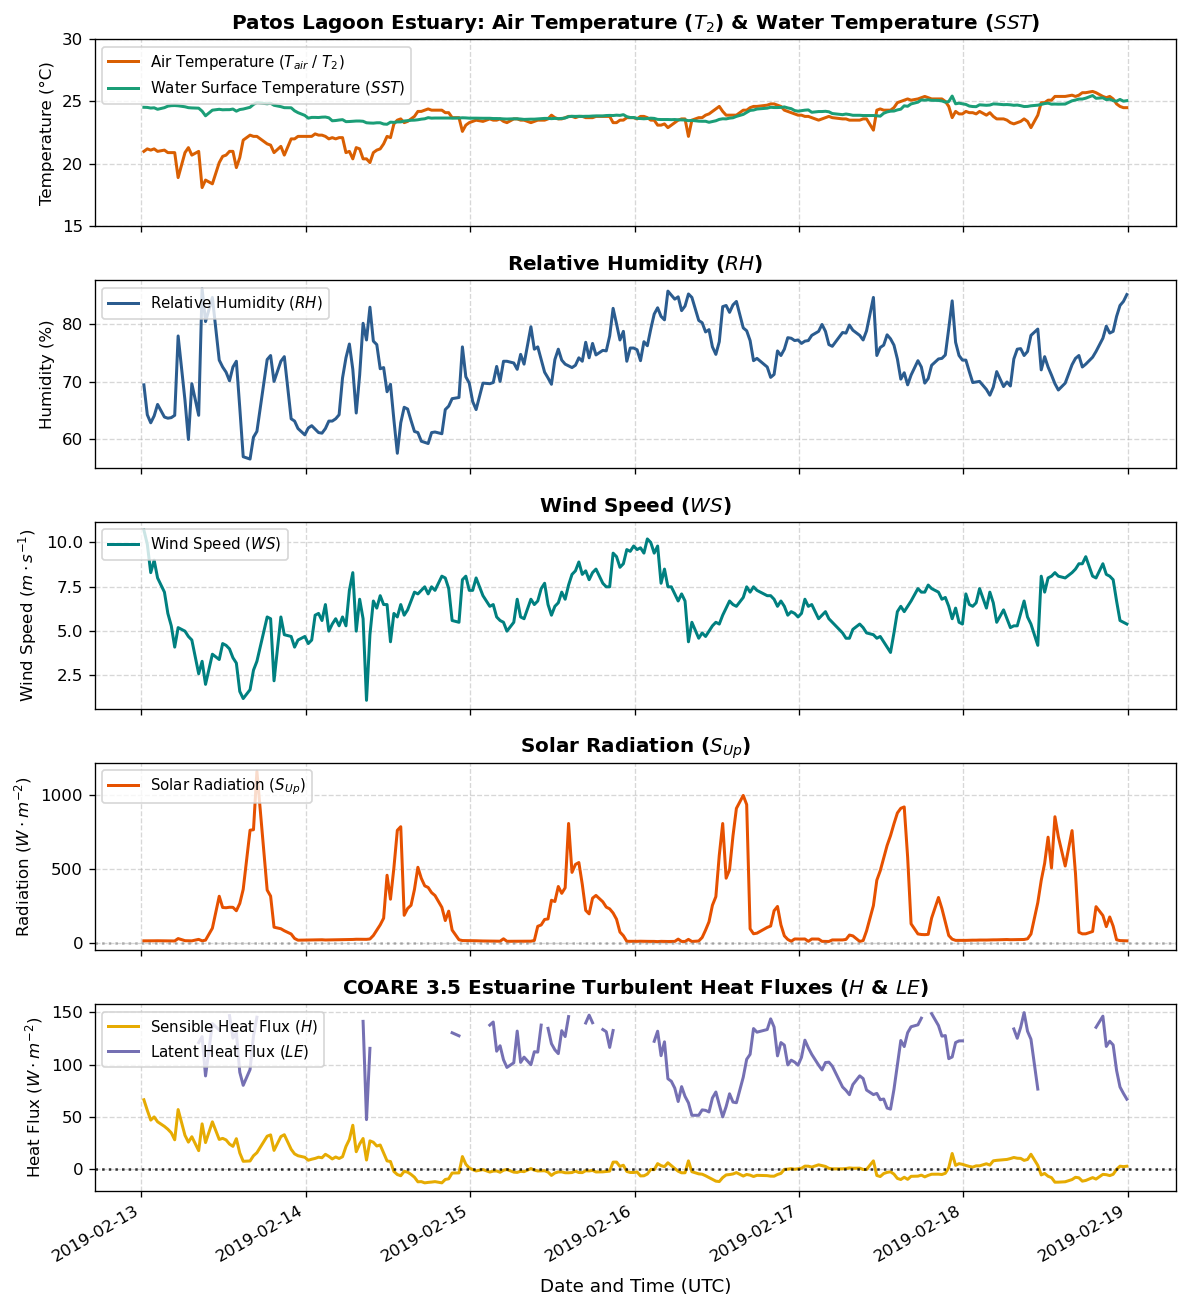

In [19]:
df_plot = df_sel.copy()

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(10, 11), sharex=True, dpi=120
)

# --- SUBPLOT 1: Temperatures ---
ax1.plot(
    df_plot.index,
    df_plot['Avg_Air_Tmp'],
    label='Air Temperature ($T_{air}$ / $T_2$)',
    color='#d95f02',
    linewidth=1.8,
)
ax1.plot(
    df_plot.index,
    df_plot['Avg_W_Tmp1'],
    label='Water Surface Temperature ($SST$)',
    color='#1b9e77',
    linewidth=1.8,
)
ax1.set_title(
    'Patos Lagoon Estuary: Air Temperature ($T_2$) & Water Temperature ($SST$)',
    fontsize=12,
    fontweight='bold',
)
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.set_ylim(15, 30)
ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 2: Relative Humidity ---
ax2.plot(
    df_plot.index,
    df_plot['Avg_Hmt'],
    label='Relative Humidity ($RH$)',
    color='#2b5c8f',
    linewidth=1.8,
)
ax2.set_title('Relative Humidity ($RH$)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Humidity (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 3: Wind Speed ---
ax3.plot(
    df_plot.index,
    df_plot['Avg_Wnd_Sp'],
    label='Wind Speed ($WS$)',
    color='#008080',
    linewidth=1.8,
)
ax3.set_title('Wind Speed ($WS$)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Wind Speed ($m \cdot s^{-1}$)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 4: Incident Solar Radiation ---
ax4.plot(
    df_plot.index,
    df_plot['Avg_Sol_Rad'],
    label='Solar Radiation ($S_{Up}$)',
    color='#e65100',
    linewidth=1.8,
)
ax4.set_title('Solar Radiation ($S_{Up}$)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Radiation ($W \cdot m^{-2}$)', fontsize=10)
ax4.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 5: Turbulent Heat Fluxes (H & LE) ---
ax5.plot(
    df_plot.index,
    df_plot['H'],
    label='Sensible Heat Flux ($H$)',
    color='#e6ab02',
    linewidth=1.8,
)
ax5.plot(
    df_plot.index,
    df_plot['LE'],
    label='Latent Heat Flux ($LE$)',
    color='#7570b3',
    linewidth=1.8,
)
ax5.set_title(
    'COARE 3.5 Estuarine Turbulent Heat Fluxes ($H$ & $LE$)',
    fontsize=12,
    fontweight='bold',
)
ax5.set_xlabel('Date and Time (UTC)', fontsize=11, labelpad=8)
ax5.set_ylabel('Heat Flux ($W \cdot m^{-2}$)', fontsize=10)
ax5.axhline(0, color='black', linestyle=':', alpha=0.8)
ax5.grid(True, linestyle='--', alpha=0.5)
ax5.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()